# Examples

In [1]:
import numpy as np

from physics_environment import Environment, Circle, Spring

## Helpers

In [2]:
def gravity(obj):
    obj.acc[1] += -10
    obj.acc[0] += 0

## Example 1

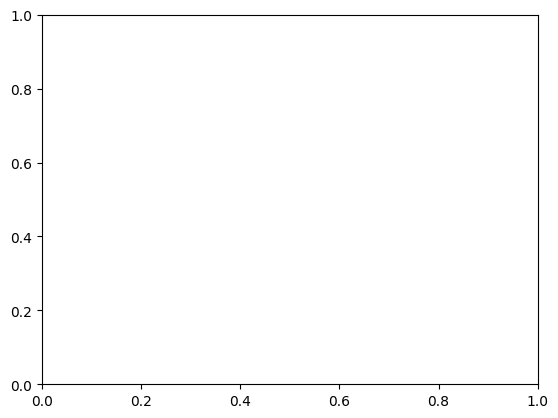

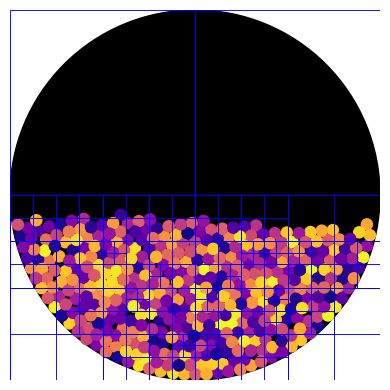

In [9]:
objects = [
    Circle(np.random.uniform(low=0.3, high=0.3),
           np.random.uniform(low=-5, high=5, size=2),
           np.random.uniform(low=0, high=0, size=2))
    for i in range(400)
]

force_fields = [gravity]

env = Environment(
    
    objects=objects,
    force_fields=force_fields,
    wall_restitution_coeff=0.8,
    circle_restitution_coeff=0.99,
    debug=False,
    display_qtree=True
    
)

env.save_animation("results/test1_q.gif", time_steps=300, sub_steps=11, dt=0.1, fps=16)

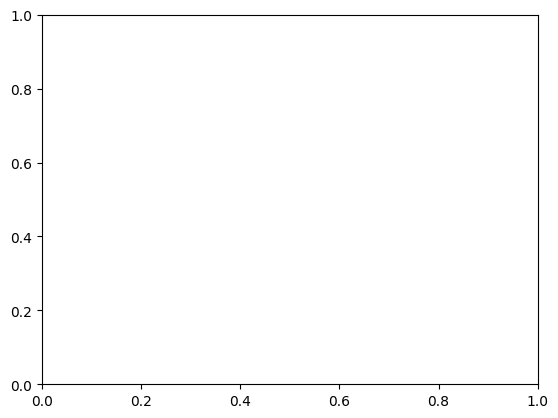

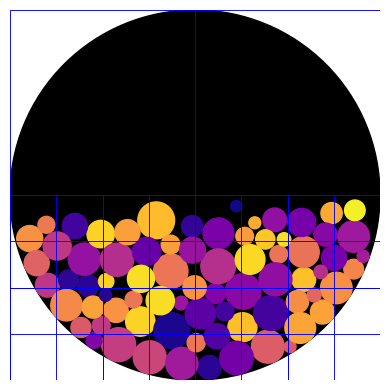

In [14]:
objects = [
    Circle(np.random.uniform(low=0.3, high=1),
           np.random.uniform(low=-5, high=5, size=2),
           np.random.uniform(low=0, high=0, size=2))
    for i in range(75)
]

force_fields = [gravity]

env = Environment(
    
    objects=objects,
    force_fields=force_fields,
    wall_restitution_coeff=0.8,
    circle_restitution_coeff=0.99,
    debug=False,
    display_qtree=True
    
)

env.save_animation("results/test1_q_2.gif", time_steps=300, sub_steps=11, dt=0.1, fps=16)

## Example 2

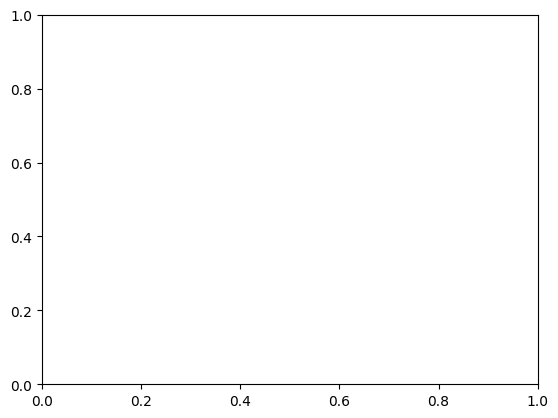

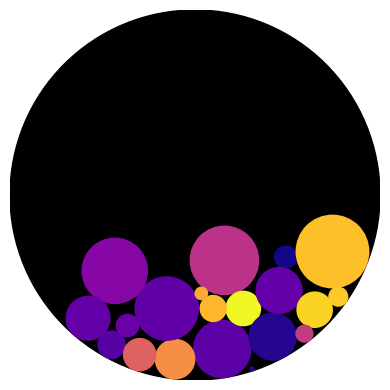

In [13]:
objects = [
    Circle(np.random.uniform(low=0.1, high=2),
           np.random.uniform(low=-5, high=5, size=2),
           np.random.uniform(low=-5, high=5, size=2))
    for i in range(20)
]

force_fields = [gravity]

env = Environment(
    
    objects=objects,
    force_fields=force_fields,
    wall_restitution_coeff=0.2,
    circle_restitution_coeff=0.2,
    debug=False,
    display_qtree=False
    
)

env.save_animation("results/test2_i.gif", time_steps=300, sub_steps=21, dt=0.05, fps=24)

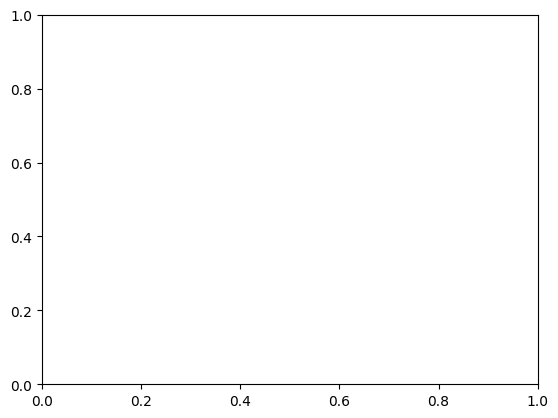

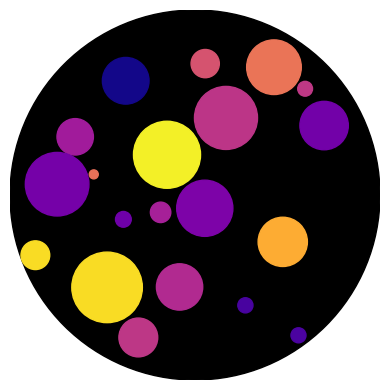

In [11]:
objects = [
    Circle(np.random.uniform(low=0.1, high=2),
           np.random.uniform(low=-5, high=5, size=2),
           np.random.uniform(low=-5, high=5, size=2))
    for i in range(20)
]

force_fields = [gravity]

env = Environment(
    
    objects=objects,
    force_fields=force_fields,
    wall_restitution_coeff=1,
    circle_restitution_coeff=1,
    debug=False,
    display_qtree=False
    
)

env.save_animation("results/test2_e.gif", time_steps=300, sub_steps=21, dt=0.05, fps=24)

## Example 3

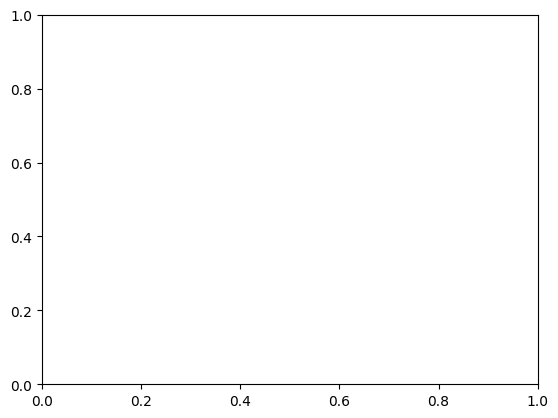

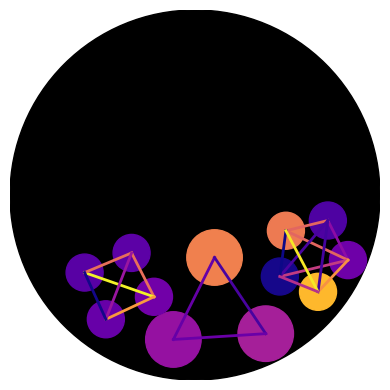

In [8]:
def create_poly(n, center, radius):

    poly = [Circle(radius=radius/2,
                   pos=[radius*np.cos(2*i*np.pi/n)+center[0], radius*np.sin(2*i*np.pi/n)+center[1]])
            for i in range(n)]

    poly_springs = []
    for i in range(n):
        for j in range(i+1, n):
            c1 = poly[i]
            c2 = poly[j]
            poly_springs.append(
                Spring(c1, c2, np.linalg.norm(c1.pos-c2.pos), 1000, 10))

    return poly, poly_springs

sides = [3, 4, 5]
centers = [[-4, 4], [0, 6], [0, 0]]
radii = [3, 2, 2]

objects = []
springs = []

for n, center, radius in zip(sides, centers, radii):

    poly, poly_springs = create_poly(n, center, radius)
    objects.extend(poly)
    springs.extend(poly_springs)

force_fields = [gravity]

env = Environment(

    objects=objects,
    force_fields=force_fields,
    springs=springs,
    wall_restitution_coeff=1,
    circle_restitution_coeff=1,
    debug=False,
    display_qtree=False

)


env.save_animation("results/test3.gif", time_steps=300, sub_steps=21, dt=0.1, fps=24)

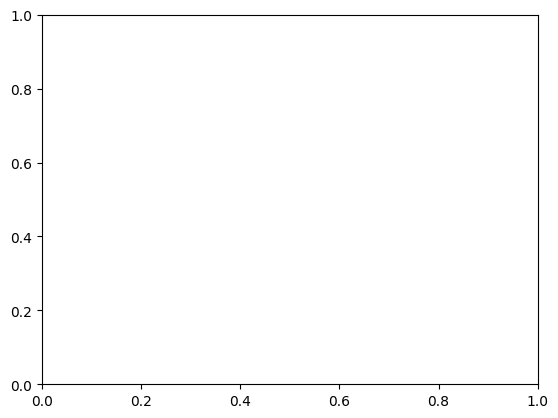

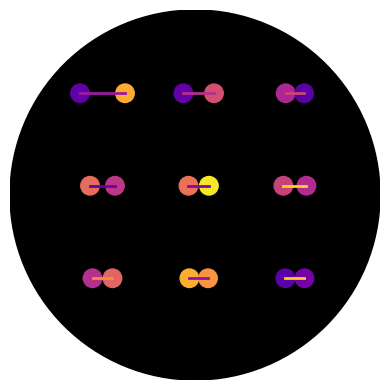

In [25]:
l1 = 4
r1 = 0.5
l2 = 4+2*r1
n = 3
m = 3

xs = -7
ys = 5.5
xc = xs
yc = ys

ks = 1
ds = 0

kc = ks
dc = ds


objects = []
springs = []

for i in range(n):
    for j in range(m):
        c1 = Circle(r1, [xc,yc])
        xc += l1
        c2 = Circle(r1, [xc,yc])
        xc += 2*r1+0.2

        spring = Spring(c1, c2, np.linalg.norm(c1.pos-c2.pos)/4, kc, dc)
        springs.append(spring)
        objects.extend([c1, c2])
        kc *= 10
        
    yc -= l2
    xc = xs
    kc = ks
    dc += 1

env = Environment(

    objects=objects,
    springs=springs,
    wall_restitution_coeff=1,
    circle_restitution_coeff=1,
    debug=False,
    display_qtree=False

)

env.save_animation("results/test3_2.gif", time_steps=300, sub_steps=21, dt=0.1, fps=24)